# 🧠Day 3 Lab 3：让 AI 会做事


在 Day 2，
我们已经让职业数字人学会了一件很重要的事：

👉 先判断你想让它干什么（routing）

但你可能已经感觉到了一个问题：

---

## 🤔 它现在的问题是？

它很会“说”。

但很多工作，不是“说出来”就算完成。

比如：

- 你让它分析一份 Excel
- 你让它查一下某个公司的最新信息
- 你让它把结果发到群里

👉 它现在做不到。

---

## 🔧 那缺的是什么？

缺的是：

👉 **工具（Tool）**

---

## 🧠 一句话定义

Tool =  
让 AI 去 **读取、搜索、计算、通知、执行动作** 的外部能力

---

## ⚖️ Model vs Tool

| 能力 | Model（模型） | Tool（工具） |
|------|--------------|-------------|
| 本质 | 会思考、会表达 | 会做事 |
| 能力 | 写文章、总结、解释 | 读文件、查网页、发消息 |
| 局限 | 不能直接操作世界 | 不能自己理解复杂语义 |

👉 所以：

**Model 负责思考  
Tool 负责行动**

---

## 🧠 回到职业数字人

现在你可以理解：

Day 1：给它大脑  
Day 2：让它知道走哪条路  
Day 3：让它真的开始“干活”

---

## 🎯 今天我们会做什么？

我们不会做很复杂的系统。

只做三件非常实用的工具：

1️⃣ 表格分析（最常用）  
2️⃣ 网页读取（看外部世界）  
3️⃣ 消息推送（把结果发出去）  

---

## 💡 一个很重要的意识

不是所有问题都要用 tool。

👉 有些问题：
直接回答更快

👉 有些问题：
必须用 tool 才能完成

---

下一步，我们就开始：

👉 给职业数字人接上第一个 tool

# Part 1：准备 Lab 3 的运行环境

今天我们会让职业数字人开始调用工具。

在正式写 tool 之前，
我们先把今天会用到的环境准备好。

这一部分会做 4 件事：

1. 安装今天会用到的工具包
2. 统一导入工具包
3. 从 `.env` 读取模型配置
4. 封装一个通用的大模型调用函数

后面所有工具，
都会基于这一部分继续往下搭。

In [ ]:
# 安装所需的库
%pip install openai python-dotenv pandas openpyxl matplotlib requests beautifulsoup4

## 第一步：导入今天会用到的工具包

今天会用到几类工具：

- `openai`：连接大模型
- `dotenv`：读取 `.env` 里的配置
- `pandas`：读取和分析表格
- `matplotlib`：画图
- `requests`：读取网页
- `BeautifulSoup`：解析网页内容
- `IPython.display`：让 Notebook 输出更好看

In [1]:
import os
import json
import requests
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams["font.sans-serif"] = [
    "Microsoft YaHei",   # Windows 常见中文字体
    "SimHei",            # 黑体
    "Arial Unicode MS"   # Mac 常见字体
]

plt.rcParams["axes.unicode_minus"] = False

from bs4 import BeautifulSoup
from dotenv import load_dotenv
from openai import OpenAI
from IPython.display import Markdown, display

In [2]:
# 定义展示函数
def show_markdown(text: str):
    """
    用 Markdown 的方式展示内容。
    后面我们不用 print，统一用这个函数展示结果。
    """
    display(Markdown(text))

## 第二步：读取 `.env` 配置

为了不把 API Key 写在代码里，
我们把模型配置统一放在 `.env` 文件中。

请确认你的 `.env` 文件里有这几项：

```env
BASE_URL=你的模型服务地址
API_KEY=你的API_KEY
MODEL_NAME=你的模型名称

In [3]:
# 加载环境变量
load_dotenv()

BASE_URL = os.getenv("BASE_URL")
API_KEY = os.getenv("API_KEY")
MODEL_NAME = os.getenv("MODEL_NAME")

if not BASE_URL or not API_KEY or not MODEL_NAME:
    show_markdown("""
### ⚠️ 环境配置未完成

请检查 `.env` 文件中是否已经写好：

- `BASE_URL`
- `API_KEY`
- `MODEL_NAME`
""")
else:
    show_markdown(f"""
### ✅ 模型配置读取成功

当前模型：

`{MODEL_NAME}`
""")


### ✅ 模型配置读取成功

当前模型：

`qwen3.6-plus`


接下来，我们创建模型客户端。

这是在创建一个“连接大模型的工具”

你可以把它理解成：

👉 你在拿起电话

API_KEY = 你的“通行证”（证明你有权限打电话）
BASE_URL = 电话号码（你要打给哪家模型服务）
client = 你手里的“电话”

In [4]:
# 创建模型客户端
client = OpenAI(
    api_key=API_KEY,
    base_url=BASE_URL
)

## 第三步：封装大模型调用函数

后面我们会反复调用大模型。

所以这里先封装成一个函数：

`call_llm()`

这样后面每次只要传入：

- 用户问题
- 系统提示词

就可以拿到模型回答。

In [5]:
# 定义调用大模型的函数
def call_llm(user_question: str, system_prompt: str = "你是一个AI职业数字人。"):
    """
    调用大模型，并返回文本结果。
    """
    try:
        messages = [
            {"role": "system", "content": system_prompt},
            {"role": "user", "content": user_question}
        ]

        response = client.chat.completions.create(
            model=MODEL_NAME,
            messages=messages
        )

        return response.choices[0].message.content

    except Exception as e:
        return f"模型调用失败：{str(e)}"

In [6]:
# 测试模型是否能正常调用
answer = call_llm(
    user_question="请用一句话介绍：AI tool 是什么？",
    system_prompt="你是一个AI课程助教，请用中文、简洁地回答。"
)

show_markdown(f"""
### 🤖 模型测试结果

{answer}
""")


### 🤖 模型测试结果

AI工具是基于人工智能技术，能自动或辅助人类高效完成各类任务的智能软件。


## 第四步：准备 @tool 装饰器

接下来我们会写很多工具函数。

为了让这些函数可以被统一管理，
我们先做一个简单的 `@tool` 装饰器。

你可以把它理解成：

👉 给函数贴上一个标签  
👉 告诉系统：这个函数是一个工具

In [7]:
# 定义一个工具箱，后面我们会把一些工具函数注册到这里。
TOOLS = {}

def tool(func):
    """
    一个教学版 @tool 装饰器。
    它会把被标记的函数注册到 TOOLS 工具箱里。
    """
    TOOLS[func.__name__] = func
    return func

In [ ]:
# 测试 @tool 是否可用
@tool
def hello_tool(name: str):
    """
    一个测试工具：返回一句问候。
    """
    return f"你好，{name}。工具已经可以使用了。"


show_markdown(f"""
### 🔧 当前已注册工具

{list(TOOLS.keys())}
""")

## Part 1 小结

到这里，Lab 3 的环境就准备好了。

我们已经完成：

- 安装今天需要的工具包
- 导入所有依赖
- 读取 `.env` 中的模型配置
- 创建大模型客户端
- 封装 `call_llm()` 函数
- 定义 `@tool` 装饰器
- 建立 `TOOLS` 工具箱

下一部分，
我们开始写第一个真正有用的工具：

👉 表格分析工具

# Part 2：Tool 1 —— 数据分析工具

这一部分，我们来做第一个真正有用的工具：

👉 数据分析工具

它会分成 4 步：

1. 读取数据
2. 让 AI 分析数据重点
3. 让 AI 判断适合画什么图
4. 调用画图工具，把图画出来

这里我们用的是一份假的销售数据：

`data/sales_data.csv`

真实工作中，
你也可以换成自己的表格文件。

## 第一步：读取 CSV 数据

这一段很简单。

我们先把 CSV 表格读进来，
然后用 `display(df.head())` 看看前几行。

这一步的目的不是做复杂分析，
只是确认：

👉 数据已经成功读进来了。

In [8]:
# 读取数据表格
file_path = "data/sales_data.csv"

df = pd.read_csv(file_path)

show_markdown("""
### 📊 数据读取成功

下面是这份表格的前几行：
""")

display(df.head())


### 📊 数据读取成功

下面是这份表格的前几行：


,月份,销售额,订单数,客户数
0,1月,12000,120,80
1,2月,15000,135,92
2,3月,18000,160,105
3,4月,17000,150,101
4,5月,22000,190,130


## 进阶：让用户提供数据路径

接 Day 2 的 routing 思路。

如果用户说“帮我分析数据”，
但没有提供表格路径，
职业数字人不应该乱猜。

它应该追问：

👉 请提供 CSV 文件路径，或者上传一个表格文件。

在 Notebook 里，
我们先用最简单的方式：

让用户输入一个文件路径。

In [9]:
def get_data_path(file_path: str = None):
    """
    获取数据路径。
    如果已经提供 file_path，就直接使用。
    如果没有提供，就请用户输入。
    """
    if file_path:
        return file_path
    
    user_path = input("请输入 CSV 文件路径，例如 data/sales_data.csv：")
    return user_path

In [10]:
selected_file_path = get_data_path("data/sales_data.csv")

df = pd.read_csv(selected_file_path)

show_markdown(f"""
### ✅ 当前读取的数据文件

`{selected_file_path}`
""")

display(df.head())


### ✅ 当前读取的数据文件

`data/sales_data.csv`


,月份,销售额,订单数,客户数
0,1月,12000,120,80
1,2月,15000,135,92
2,3月,18000,160,105
3,4月,17000,150,101
4,5月,22000,190,130


## 第二步：让 AI 分析数据重点

现在我们把“读取数据 + AI 总结”封装成一个 tool。

这个工具会做两件事：

1. 展示表格前几行
2. 让 AI 总结这份数据的重点

注意：

AI 不是凭空分析。

我们会把真实数据内容交给它，
让它基于数据做总结。

In [12]:
# 定义一个工具函数，专门用来分析 CSV 数据的。
@tool
def analyze_csv_tool(file_path: str):
    """
    读取 CSV 数据，并让 AI 总结数据重点。
    """
    try:
        df = pd.read_csv(file_path)

        data_text = df.to_csv(index=False)

        system_prompt = """
        你是一个数据分析助理。
        请根据用户提供的 CSV 数据，用中文做简洁分析。

        要求：
        1. 总结 3 个最重要的发现
        2. 说明是否有明显异常
        3. 给出 1 条业务建议
        4. 不要编造数据里没有的信息
        5. 回答要简洁，适合普通职场人阅读
        """

        user_question = f"""
        请分析下面这份 CSV 数据：

        {data_text}
        """

        result = call_llm(
            user_question=user_question,
            system_prompt=system_prompt
        )

        return result

    except Exception as e:
        return f"数据分析失败：{str(e)}"

In [13]:
# 使用我们刚定义的工具函数来分析 CSV 数据。
analysis_result = analyze_csv_tool("data/sales_data.csv")

show_markdown(f"""
### 🤖 AI 数据分析结果

{analysis_result}
""")


### 🤖 AI 数据分析结果

📊 **3个核心发现**
1. **全年呈强劲增长态势**：销售额从1月的12,000元升至12月的42,000元（累计增长250%），订单数与客户数同步稳步攀升，业务处于快速扩张期。
2. **三指标高度同步，增长结构健康**：销售额涨幅与客户数、订单数增幅基本一致，未出现“只涨营收不涨单量”或“只拉新不转化”的失衡现象。
3. **存在两次小幅节奏回调**：4月（较3月）和9月（较8月）三项指标均出现约3%~5%的微降，但次月即恢复上行，未影响全年增长主轴。

🔍 **异常说明**
无明显数据异常。4月与9月的回落属常规业务波动，跌幅温和、无断崖式下跌或逻辑矛盾，数据整体连贯可靠。

💡 **业务建议**
建议在维持现有拉新势头的同时，针对4月、9月的波谷期提前制定淡季促活方案（如季度会员日/组合优惠），并逐步尝试提升客单价，将“单量驱动”升级为“单量+利润”双轮增长。


## 第三步：让 AI 决定画什么图

真实工作里，
数据分析通常不会只看文字总结。

很多时候，
图更直观。

但这里我们不把图写死。

我们让 AI 根据数据内容判断：

👉 应该画什么图  
👉 横轴用哪一列  
👉 纵轴用哪一列  
👉 为什么这样画  

今天我们先支持几种最常见的图：

- 折线图：适合看趋势
- 柱状图：适合比较大小
- 饼图：适合看占比
- 散点图：适合看两个数值之间的关系

In [14]:
# 定义一个工具函数，让 AI 根据数据内容，决定适合画什么图。
@tool
def choose_chart_with_ai(file_path: str):
    """
    让 AI 根据数据内容，决定适合画什么图。
    """
    df = pd.read_csv(file_path)

    columns_info = {
        "列名": list(df.columns),
        "数据类型": df.dtypes.astype(str).to_dict(),
        "数据预览": df.head().to_dict(orient="records")
    }

    system_prompt = """
    你是一个数据可视化助理。
    请根据用户提供的数据结构，选择一种最适合的图表。

    你只能从下面四种图里选择：
    1. line：折线图，适合展示趋势
    2. bar：柱状图，适合比较大小
    3. pie：饼图，适合展示占比
    4. scatter：散点图，适合展示两个数值变量之间的关系

    请只返回 JSON，不要返回多余解释。

    JSON 格式如下：
    {
    "chart_type": "line",
    "x_column": "月份",
    "y_column": "销售额",
    "reason": "选择原因"
    }
    """

    user_question = f"""
    下面是数据结构：

    {json.dumps(columns_info, ensure_ascii=False, indent=2)}

    请判断最适合画什么图。
    """

    result = call_llm(
        user_question=user_question,
        system_prompt=system_prompt
    )

    return result

In [15]:
# 查看 AI 推荐的图表方案
chart_plan_text = choose_chart_with_ai("data/sales_data.csv")

show_markdown(f"""
### 🤖 AI 推荐的图表方案

```json
{chart_plan_text}
```
""")


### 🤖 AI 推荐的图表方案

```json
{
  "chart_type": "line",
  "x_column": "月份",
  "y_column": "销售额",
  "reason": "数据包含明确的时间维度（月份）与连续数值指标，折线图最适合直观展示各指标随时间推移的变化趋势。"
}
```


## 第四步：调用画图工具

刚刚 AI 已经决定了：

- 画什么图
- 用哪一列做横轴
- 用哪一列做纵轴

接下来，
工具负责真正把图画出来。


In [16]:
# 定义一个工具函数，根据 AI 推荐的图表方案，画出对应的图。
@tool
def plot_chart_tool(file_path: str, chart_type: str, x_column: str, y_column: str):
    """
    根据指定图表类型和字段画图。
    支持 line、bar、pie、scatter。
    """
    try:
        df = pd.read_csv(file_path)

        plt.figure(figsize=(8, 4))

        if chart_type == "line":
            plt.plot(df[x_column], df[y_column], marker="o")
            plt.xlabel(x_column)
            plt.ylabel(y_column)
            plt.title(f"{y_column}趋势图")

        elif chart_type == "bar":
            plt.bar(df[x_column], df[y_column])
            plt.xlabel(x_column)
            plt.ylabel(y_column)
            plt.title(f"{y_column}对比图")

        elif chart_type == "pie":
            plt.pie(df[y_column], labels=df[x_column], autopct="%1.1f%%")
            plt.title(f"{y_column}占比图")

        elif chart_type == "scatter":
            plt.scatter(df[x_column], df[y_column])
            plt.xlabel(x_column)
            plt.ylabel(y_column)
            plt.title(f"{x_column} 与 {y_column} 关系图")

        else:
            return f"暂不支持这种图表类型：{chart_type}"

        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()

        return "图表已生成。"

    except Exception as e:
        return f"画图失败：{str(e)}"

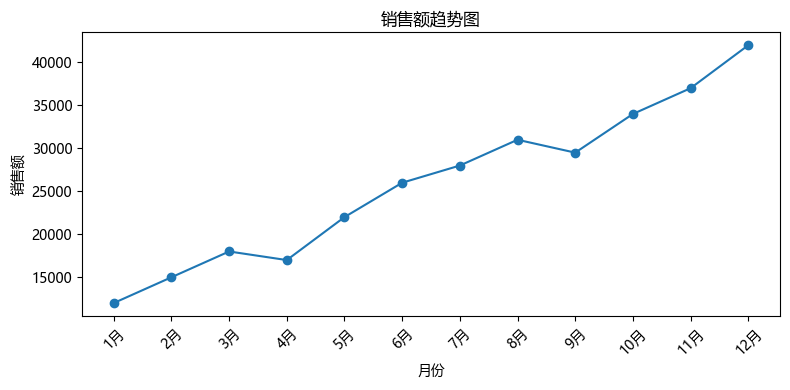


### 📈 画图工具返回结果

图表已生成。

### 为什么画这张图？

数据包含明确的时间维度（月份）与连续数值指标，折线图最适合直观展示各指标随时间推移的变化趋势。


In [17]:
# 根据 AI 推荐的图表方案，画出对应的图。
chart_plan = json.loads(chart_plan_text)

chart_result = plot_chart_tool(
    file_path="data/sales_data.csv",
    chart_type=chart_plan["chart_type"],
    x_column=chart_plan["x_column"],
    y_column=chart_plan["y_column"]
)

show_markdown(f"""
### 📈 画图工具返回结果

{chart_result}

### 为什么画这张图？

{chart_plan["reason"]}
""")

## 第五步：封装成完整的数据分析流程

现在我们把刚刚几步合在一起：

1. 读取数据
2. 展示表格前几行
3. AI 总结数据
4. AI 选择图表
5. 工具画图

这样，
一个更完整的数据分析工具就出来了。

In [18]:
# 定义一个完整的数据分析工具，把前面所有步骤串在一起。
@tool
def full_data_analysis_tool(file_path: str):
    """
    完整数据分析工具：
    读取数据、AI总结、AI选择图表、工具画图。
    """
    try:
        df = pd.read_csv(file_path)

        show_markdown("""
        ### 📊 表格预览
        """)
        display(df.head())

        analysis_result = analyze_csv_tool(file_path)

        chart_plan_text = choose_chart_with_ai(file_path)
        chart_plan = json.loads(chart_plan_text)

        plot_result = plot_chart_tool(
            file_path=file_path,
            chart_type=chart_plan["chart_type"],
            x_column=chart_plan["x_column"],
            y_column=chart_plan["y_column"]
        )

        final_result = f"""
        ### 🤖 AI 数据分析结果

        {analysis_result}

        ---

        ### 📈 AI 推荐图表

        - 图表类型：{chart_plan["chart_type"]}
        - 横轴：{chart_plan["x_column"]}
        - 纵轴：{chart_plan["y_column"]}
        - 推荐原因：{chart_plan["reason"]}

        {plot_result}
        """

        return final_result

    except Exception as e:
        return f"完整数据分析失败：{str(e)}"


        ### 📊 表格预览
        

,月份,销售额,订单数,客户数
0,1月,12000,120,80
1,2月,15000,135,92
2,3月,18000,160,105
3,4月,17000,150,101
4,5月,22000,190,130


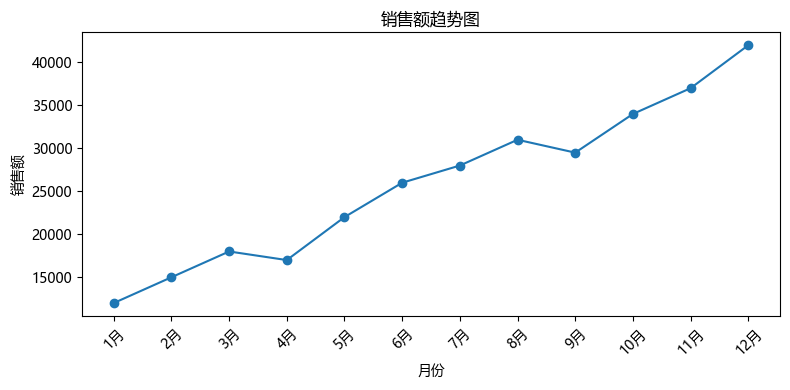


        ### 🤖 AI 数据分析结果

        以下是基于您提供数据的简洁分析：

**📊 3个最重要发现**
1. **整体业务高速扩张**：全年销售额、订单数与客户数均呈稳定上升趋势。12月销售额达4.2万，约为1月的3.5倍，业务规模实现量级跨越。
2. **客单价温和提升**：平均单笔订单金额（销售额÷订单数）从1月的100元逐步增至12月的约117元，说明客户消费力或高价值商品占比在持续优化。
3. **年底旺季拉动明显**：10-12月环比增速最快，呈现典型的年底消费/冲刺特征；前三季度增速平稳，为年底放量打下基础。

**🔍 是否有明显异常**
数据无逻辑错误或极端离群值。仅**4月**和**9月**出现短暂环比下滑（如4月销售额较3月下降约5.6%），在整体上行曲线中属于正常的季节性回调或营销空窗期波动，非数据异常。

**💡 1条业务建议**
建议在4月、9月等阶段性回落期提前部署“淡季促销”或会员复购激励活动，以平滑业绩波动；同时利用年底已扩大的客户基数，重点优化高客单价组合与售后服务，将流量增长转化为长期留存。

        ---

        ### 📈 AI 推荐图表

        - 图表类型：line
        - 横轴：月份
        - 纵轴：销售额
        - 推荐原因：数据包含时间序列（月份）和对应的连续数值指标，折线图最适合清晰展示业务数据随时间变化的趋势。

        图表已生成。
        

In [19]:
final_result = full_data_analysis_tool("data/sales_data.csv")

show_markdown(final_result)

## 真实业务里的提醒

今天我们用的是一份很简单的 CSV 表格。

但真实工作里的表格，
经常没有这么干净。

比如：

- 有合并单元格
- 表头不在第一行
- 一个文件里有多个 sheet
- 有空行、备注行、说明行
- 同一列里混了不同类型的数据
- 不同部门的表格格式不统一

这些都会影响程序读取数据，
也会影响 AI 分析数据的稳定性。

---

## 更好的做法

最好的方法是：

👉 统一表格格式

比如：

- 第一行就是表头
- 不使用合并单元格
- 每一列只放一种数据
- 字段名清楚
- 不在数据区域里写备注

---

## 退而求其次

如果业务表格确实很复杂，
那就需要定制化处理。

比如：

- 指定读取哪个 sheet
- 指定从第几行开始读取
- 先清洗数据
- 再交给 AI 分析

所以你可以这样理解：

👉 简单表格，可以用通用工具  
👉 复杂表格，需要定制化工具

## 拓展练习

现在请你想一想：

在你的真实工作里，
做数据分析时，除了读取、总结和画图，
还会做什么？

比如：

- 是否需要分析多个表？
- 是否需要对比不同部门的数据？
- 是否需要自动找异常值？
- 是否需要生成周报或月报？
- 是否需要把分析结果发给同事？
- 是否需要把结果保存成 Excel 或 PPT？

你可以试着扩展今天的工具：

👉 让它读取多个 CSV  
👉 让它自动判断异常  
👉 让它生成一段汇报文字  
👉 让它把分析结果推送到测试群  

今天先做到这里就很好。

因为你已经完成了职业数字人的第一种工具能力：

👉 读数据，并做出初步判断。

# Part 3：Tool 2 —— 网页读取工具

刚刚我们让职业数字人学会了：

👉 读取表格，分析数据

但真实工作中，
还有一类非常常见的需求：

👉 查外部信息

比如：

- 查某个公司最近做了什么
- 查某个概念是什么意思
- 查一个行业的公开信息
- 查一个技术的官方介绍

---

## 🧠 这一部分要做什么？

我们要做一个新的 tool：

👉 网页读取工具

它会做三件事：

1. 读取一个网页
2. 提取网页里的文字
3. 让 AI 帮你总结内容

---

## 💡 你可以这样理解

刚才的数据工具，是：

👉 职业数字人的“数据眼睛”

现在这个工具，是：

👉 职业数字人的“外部眼睛”

## 第一步：读取公司官网页面

我们用一个真实的企业网页来演示：

👉 中伟股份官网 - 联系我们页面

https://www.cngrgf.com.cn/lxwm.html

---

这个页面的特点是：

- 公开网页
- 内容结构清晰
- 信息很具体（电话、邮箱、地址）

非常适合做教学。

In [20]:
# 测试一下网页读取功能，看看能不能拿到内容。

url = "https://www.cngrgf.com.cn/lxwm.html"

response = requests.get(url)

if response.status_code == 200:
    show_markdown("""
### 🌐 网页读取成功

已经成功拿到网页内容 ✅
""")
else:
    show_markdown(f"""
### ⚠️ 网页读取失败

状态码：{response.status_code}
""")


### 🌐 网页读取成功

已经成功拿到网页内容 ✅


## 第二步：解析网页内容

网页本质是 HTML。

我们需要把里面的文字提取出来，
再交给 AI 使用。

这里我们要用到 BeautifulSoup

In [21]:
# 解析网页内容，看看能不能提取到文本。

soup = BeautifulSoup(response.text, "html.parser")

text = soup.get_text()

show_markdown(f"""
### 📄 网页内容（节选）

{text[:500]}
""")


### 📄 网页内容（节选）





联系方式 - 中伟新材料股份有限公司


























CN



CN


EN








首页


关于中伟


公司介绍
研发创新
企业文化





核心业务


中伟产业生态
新能源电池材料
应用领域


动力交通
智能终端
绿色储能

新能源关键金属材料





全球发展


产业布局
合作客户





ESG


新闻资讯


公司新闻
通知公告
视频中心





投资者关系


管理层介绍
招股文件
业绩报告
H股公告与通函
其他事项
招股文件
业绩报告
H股公告与通函
A股公告
推介会材料
其他事项
IR联系通道





联系我们


人才招聘
联系方式











 cngr@cngrgf.com.cn
                







返回顶部








联系我们










中伟新材料股份有限公司


 











 


联系电话：0856-3323580




 


公开邮箱：cngr@cngrgf.com.cn 




 


地       


## 第三步：封装网页读取 Tool

现在我们把刚刚这几步封装成一个工具。

这个工具会：

1. 读取网页
2. 提取文字
3. 返回给 AI

In [22]:
@tool
def read_webpage_tool(url: str):
    """
    读取网页并返回文本内容
    """
    try:
        response = requests.get(url, timeout=10)

        if response.status_code != 200:
            return f"网页读取失败，状态码：{response.status_code}"

        soup = BeautifulSoup(response.text, "html.parser")
        text = soup.get_text()

        return text[:3000]

    except Exception as e:
        return f"网页读取失败：{str(e)}"

In [23]:
# 使用工具函数读取网页内容。
web_text = read_webpage_tool("https://www.cngrgf.com.cn/lxwm.html")

show_markdown(f"""
### 🔧 工具返回内容（节选）

{web_text[:800]}
""")


### 🔧 工具返回内容（节选）





联系方式 - 中伟新材料股份有限公司


























CN



CN


EN








首页


关于中伟


公司介绍
研发创新
企业文化





核心业务


中伟产业生态
新能源电池材料
应用领域


动力交通
智能终端
绿色储能

新能源关键金属材料





全球发展


产业布局
合作客户





ESG


新闻资讯


公司新闻
通知公告
视频中心





投资者关系


管理层介绍
招股文件
业绩报告
H股公告与通函
其他事项
招股文件
业绩报告
H股公告与通函
A股公告
推介会材料
其他事项
IR联系通道





联系我们


人才招聘
联系方式











 cngr@cngrgf.com.cn
                







返回顶部








联系我们










中伟新材料股份有限公司


 











 


联系电话：0856-3323580




 


公开邮箱：cngr@cngrgf.com.cn 




 


地       址：贵州省铜仁市玉屏侗族自治县大龙经济开发区中国西部新能源产业园 








关于网络、数据与信息安全和信息内容相关投诉举报及漏洞反馈请通过上述联系方式提交！

 






在线留言






姓名

*


电话

*




图片验证码

*




















友情链接
中伟集团




 联系我们
                

                    联系电话：0856-3323580
                    公开邮箱：cngr@cngrgf.com.cn
                    地址：贵州省


## 第四步：带着问题去读网页（更真实的用法）

真实情况是：

👉 用户会给你一个网站  
👉 同时告诉你他想知道什么  

比如：

- 这家公司是做什么的？
- 有没有联系方式？
- 最近有没有什么动态？
- 有没有招聘信息？

---

所以更真实的方式是：

👉 带着问题去读网页

In [24]:
# 定义一个函数，让 AI 根据网页内容回答问题。
def ask_webpage(content: str, question: str):
    system_prompt = """
    你是一个网页信息分析助手。

    你会根据用户的问题，
    从网页内容中提取相关信息并回答。

    要求：
    1. 只基于网页内容回答
    2. 如果找不到答案，就说“网页中未找到相关信息”
    3. 用中文回答
    4. 简洁清晰
    """

    user_prompt = f"""
    用户问题：
    {question}

    网页内容：
    {content}
    """

    return call_llm(user_prompt, system_prompt)

In [25]:
# （测试：不同问题）
question = "这家公司有没有公开的联系方式？"

answer = ask_webpage(web_text, question)

show_markdown(f"""
### 🤖 回答

{answer}
""")


### 🤖 回答

有的。根据网页内容，该公司（中伟新材料股份有限公司）的公开联系方式如下：
- **联系电话**：0856-3323580
- **公开邮箱**：cngr@cngrgf.com.cn
- **地址**：贵州省铜仁市玉屏侗族自治县大龙经济开发区中国西部新能源产业园


In [26]:
# （测试：不同问题）
question = "这个页面主要提供了什么信息？"

answer = ask_webpage(web_text, question)

show_markdown(f"""
### 🤖 回答

{answer}
""")


### 🤖 回答

该页面主要为**中伟新材料股份有限公司**的**“联系我们/联系方式”**页面，主要提供以下信息：

1. **公司联系方式**：联系电话（0856-3323580）、公开邮箱（cngr@cngrgf.com.cn）及公司详细地址（贵州省铜仁市大龙经济开发区）。
2. **在线留言功能**：提供姓名、电话和图片验证码的在线表单，方便访客提交咨询。
3. **其他说明**：包含网络、数据与信息安全投诉举报的提交指引，以及网站导航菜单、版权备案（ICP）和技术支持信息。


## 第五步：封装成完整网页工具

现在我们把两步合在一起：

👉 读取网页 + 提取信息

In [27]:
@tool
def web_qa_tool(url: str, question: str):
    """
    通用网页问答工具：
    用户提供网址 + 问题，AI基于网页回答
    """
    try:
        content = read_webpage_tool(url)
        answer = ask_webpage(content, question)
        return answer

    except Exception as e:
        return f"网页分析失败：{str(e)}"

In [28]:
# 测试一下我们这个网页问答工具，看看能不能直接给网址和问题，就得到答案。
result = web_qa_tool(
    url="https://www.cngrgf.com.cn/lxwm.html",
    question="这家公司有没有联系方式？"
)

show_markdown(f"""
### 🌐 网页问答结果

{result}
""")


### 🌐 网页问答结果

有的。该公司（中伟新材料股份有限公司）的联系方式如下：

* **联系电话**：0856-3323580
* **公开邮箱**：cngr@cngrgf.com.cn
* **地址**：贵州省铜仁市玉屏侗族自治县大龙经济开发区中国西部新能源产业园


## ⚠️ 使用提醒

这个工具适合：

- 查询公司官网信息
- 查公开联系方式
- 查公开资料

---

但不适合：

- 登录后的页面
- 动态加载内容
- 有反爬的网站

---

👉 我们只处理公开信息

## 🔍 拓展阅读

如果你以后想做更复杂的网页操作：

比如：

- 自动登录网站
- 点击按钮
- 抓取动态内容

可以了解：

- Selenium
- Playwright

---


# Part 4：Tool 3 —— 群消息推送工具

前面两个工具都在帮职业数字人获取信息：

- 表格分析工具：读取内部数据
- 网页读取工具：读取外部公开信息

接下来这个工具不一样。

它开始执行动作：

👉 把结果发送到测试群

---

## 什么是 Webhook？

你可以先把 Webhook 理解成：

👉 一个专门接收消息的网址

平时我们打开网址，是为了看网页。

但 Webhook 这个网址，
不是给人看的，
是给程序用的。

当程序把消息发送到这个网址，
平台就会把消息转发到对应的群里。

---

## Webhook 可以用来做什么？

比如：

- 把表格分析结果发到测试群
- 把网页摘要发到项目群
- 发现异常后发送提醒
- 自动推送工作进度

---

## 今天的安全原则

为了避免误发消息，
我们今天只做测试群推送。

并且固定三个原则：

1. 先预览
2. 再发送
3. 不发送隐私和敏感信息

## 第一步：准备 Webhook 地址

在真实使用中，
你需要在聊天工具里创建一个机器人。

常见平台：

- 企业微信
- 飞书
- Slack

创建完成后，
你会拿到一个 Webhook URL。

---

## 第二步：写入 `.env`

请在你的 `.env` 文件中增加一行：

WEBHOOK_URL=你的Webhook地址

---

⚠️ 注意：

- 不要把 Webhook 写死在代码里
- 不要分享给别人
- 这个地址相当于“群的入口”

In [29]:
# 读取 Webhook URL，看看是否配置成功。
load_dotenv(override=True)

WEBHOOK_URL = os.getenv("WEBHOOK_URL")

if WEBHOOK_URL:
    show_markdown("### ✅ Webhook 已加载")
else:
    show_markdown("### ⚠️ 还是没有读取到 WEBHOOK_URL")

### ✅ Webhook 已加载

## 第三步：测试发送一条消息

我们先不接 AI。

只测试一件事：

👉 能不能成功把消息发到群里

In [30]:
# 定义一个函数，测试发送消息到企业微信 Webhook。
def send_test_message(webhook_url: str, message: str):
    payload = {
        "msgtype": "text",
        "text": {
            "content": message
        }
    }

    try:
        response = requests.post(webhook_url, json=payload)

        if response.status_code == 200:
            return "发送成功 ✅"
        else:
            return f"发送失败，状态码：{response.status_code}"

    except Exception as e:
        return f"发送失败：{str(e)}"

In [31]:
# 发送测试消息，看看能不能成功。
test_result = send_test_message(
    WEBHOOK_URL,
    "测试消息：职业数字人已经可以发送消息了 🚀"
)

show_markdown(f"""
### 📤 发送结果

{test_result}
""")


### 📤 发送结果

发送成功 ✅


## 到这里，你完成了什么？

你已经完成了：

👉 第一次“让程序往群里发消息”

---

这是一个很重要的变化：

之前：

AI 只是在屏幕里回答你

现在：

👉 它开始影响外部世界了

---

下一步，我们会做：

👉 把这个能力封装成一个 tool

👉 并且接到职业数字人里

## 第四步：封装成消息推送 Tool

现在我们把发送消息的能力封装成一个 tool。

但注意：

👉 不要一上来就直接发送

因为消息一旦发到群里，
就会影响外部世界。

所以我们先做一个预览机制：

1. 先预览消息内容
2. 确认没有问题
3. 再发送到测试群

这也是企业场景里非常重要的一点：

👉 能执行，也要可控

In [32]:
# 定义一个函数，预览即将发送的消息。
def preview_message(message: str):
    """
    预览即将发送的消息。
    """
    show_markdown(f"""
    ### 👀 消息预览

    下面这段内容将被发送到测试群：

    ---

    {message}

    ---
    """)

In [33]:
# 封装一个工具函数，既可以预览消息，也可以发送消息。
@tool
def send_message_tool(message: str, confirm: bool = False):
    """
    发送消息到测试群。

    参数：
    - message: 要发送的消息内容
    - confirm: 是否确认发送
    """
    if not confirm:
        preview_message(message)
        return "消息已预览。请确认后再发送。"

    if not WEBHOOK_URL:
        return "发送失败：未检测到 WEBHOOK_URL，请检查 .env 配置。"

    payload = {
        "msgtype": "text",
        "text": {
            "content": message
        }
    }

    try:
        response = requests.post(WEBHOOK_URL, json=payload, timeout=10)

        if response.status_code == 200:
            return "消息发送成功 ✅"
        else:
            return f"消息发送失败，状态码：{response.status_code}"

    except Exception as e:
        return f"消息发送失败：{str(e)}"

## 第五步：先预览，不发送

我们先测试预览。

这里 `confirm=False`，
所以消息不会真的发出去。

它只会显示在 Notebook 里。

In [34]:
message = """
【职业数字人测试消息】

刚刚完成了一次数据分析。
这是一次测试推送，不代表正式业务结果。
"""

preview_result = send_message_tool(message, confirm=False)

show_markdown(f"""
### 📌 当前状态

{preview_result}
""")


    ### 👀 消息预览

    下面这段内容将被发送到测试群：

    ---

    
【职业数字人测试消息】

刚刚完成了一次数据分析。
这是一次测试推送，不代表正式业务结果。


    ---
    


### 📌 当前状态

消息已预览。请确认后再发送。


## 第六步：确认后发送

确认内容没问题后，
再把 `confirm` 改成 `True`。

这样消息才会真正发送到测试群。

In [35]:
# 
send_result = send_message_tool(message, confirm=True)

show_markdown(f"""
### 📤 发送结果

{send_result}
""")


### 📤 发送结果

消息发送成功 ✅


## 到这里，你完成了什么？

你已经把“发消息”封装成了一个 tool。

这个 tool 有两个状态：

- `confirm=False`：只预览，不发送
- `confirm=True`：确认发送

这就让职业数字人有了第一只“手”。

它不只是读取信息、分析信息，
还可以把结果发出去。

下一步，
我们会把前面的分析结果，
真正接到这个推送工具里。

## Part 5 把工具接进职业数字人的流程
## 第一步：接入任务判断模块

在 Day 2，我们已经做过一件事：

👉 判断用户输入属于哪一类任务

为了避免重复写代码，
我们把这部分逻辑封装成了：

`task_router.py`

---

它的作用很简单：

👉 输入一句话  
👉 输出一个任务类型

In [36]:
# 导入任务分类和路由函数
from task_router import classify_task, route_task

## 第二步：测试任务判断

我们先不接工具。

只测试一件事：

👉 系统能不能判断任务类型

In [37]:
# 测试一下任务分类函数，看看能不能根据用户输入，判断出这是一个数据分析的任务。
user_input = "帮我分析一下这个销售数据"

task_type = classify_task(user_input, call_llm)

show_markdown(f"""
### 🧠 任务判断结果

用户输入：

{user_input}

判断任务类型：

👉 {task_type}
""")


### 🧠 任务判断结果

用户输入：

帮我分析一下这个销售数据

判断任务类型：

👉 data_analysis


In [38]:
# 再测试一下，看看能不能判断出这是一个需要查网页信息的任务。
user_input = "帮我查一下这个公司最近的公开信息"

task_type = classify_task(user_input, call_llm)

show_markdown(f"""
### 🧠 任务判断结果

👉 {task_type}
""")


### 🧠 任务判断结果

👉 web_search


## 到这里，你完成了什么？

你已经让职业数字人恢复了一个能力：

👉 先判断任务类型

---

接下来，

我们要做下一步：

👉 根据任务类型，决定如何调用工具

## 第三步：根据任务类型调用对应工具

现在系统已经可以判断任务类型了。

接下来要做的是：

👉 不同任务，走不同处理方式

---

如果任务是：

- `data_analysis`：调用数据分析工具
- `web_search`：调用网页问答工具
- `send_message`：调用消息推送工具

---

如果任务是：

- `profile`：基于 `data/CV.txt` 和 `data/work_log.txt` 回答
- `writing`：先询问写作场景、语气和目标
- `work_planning`：先询问任务清单、时间范围和优先级
- `clarify`：最多追问 3 次

---

这一步完成后，
职业数字人就真正从“会判断”，进入了“会行动”。

In [39]:
# 读取文本文件的函数
def read_text_file(file_path):
    try:
        with open(file_path, "r", encoding="utf-8") as f:
            return f.read()
    except Exception:
        return ""

In [40]:
# profile 任务处理
def answer_profile_question(user_input):
    cv_text = read_text_file("data/CV.txt")
    work_log_text = read_text_file("data/work_log.txt")

    system_prompt = f"""
    你是一个职业数字人助手。

    请根据下面资料回答用户问题。

    资料一：CV
    {cv_text}

    资料二：work log
    {work_log_text}

    要求：
    1. 只基于资料回答
    2. 如果资料里没有，就说“资料中暂时没有相关信息”
    3. 用中文回答
    4. 简洁、友好、专业
    """

    return call_llm(user_input, system_prompt)

In [41]:
# writing 和 work_planning 任务处理
def ask_writing_requirements():
    return """
    我可以帮你写。

    为了写得更准确，请你补充三点：

    1. 这段文字用在什么场景？
    2. 你希望语气正式一点、自然一点，还是更有感染力一点？
    3. 有没有必须包含的信息？
    """


def ask_work_planning_requirements():
    return """
    我可以帮你做工作规划。

    请你先补充三点：

    1. 你要规划的是哪段时间？比如今天、本周、下周。
    2. 目前手上有哪些任务？
    3. 哪些任务最紧急或最重要？
    """

In [42]:
# clarify 最多追问 3 次，如果还不清楚，就让用户重新输入需求。                   
clarify_count = 0

def ask_clarify_question():
    global clarify_count

    clarify_count += 1

    if clarify_count <= 3:
        return f"""
        我还需要再确认一下你的需求。

        请你补充一点具体信息：

        你是想让我写东西、分析数据、查网页，还是发送消息？

        （这是第 {clarify_count} 次澄清）
        """
    else:
        return """
        我先不继续追问了。

        你可以先按下面这个格式重新告诉我：

        1. 你想完成什么任务？
        2. 有没有文件、网址或消息内容？
        3. 希望最后输出成什么形式？
        """

### 统一处理函数，根据不同任务类型，调用不同的处理函数。

In [43]:
# 定义一个函数，综合使用前面所有的工具，根据用户输入的需求，自动判断任务类型，并调用对应的工具来完成任务。
def handle_user_task(
    user_input,
    file_path=None,
    url=None,
    question=None,
    message=None,
    confirm=False
):
    task_type = classify_task(user_input, call_llm)

    if task_type == "data_analysis":
        if not file_path:
            return "请先提供 CSV 文件路径，例如：data/sales_data.csv"
        return full_data_analysis_tool(file_path)

    elif task_type == "web_search":
        if not url:
            return "请先提供网页 URL。"
        if not question:
            question = user_input
        return web_qa_tool(url, question)

    elif task_type == "send_message":
        if not message:
            message = user_input
        return send_message_tool(message, confirm=confirm)

    elif task_type == "profile":
        return answer_profile_question(user_input)

    elif task_type == "writing":
        return ask_writing_requirements()

    elif task_type == "work_planning":
        return ask_work_planning_requirements()

    else:
        return ask_clarify_question()

## 第四步：测试数据分析任务

我们先测试第一类工具任务：

👉 数据分析

如果系统判断这是 `data_analysis`，
它就会调用：

`full_data_analysis_tool()`


        ### 📊 表格预览
        

,月份,销售额,订单数,客户数
0,1月,12000,120,80
1,2月,15000,135,92
2,3月,18000,160,105
3,4月,17000,150,101
4,5月,22000,190,130


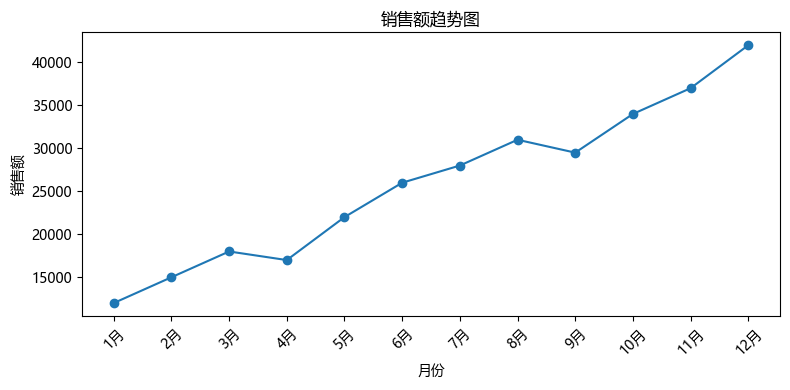


### 🤖 系统输出


        ### 🤖 AI 数据分析结果

        以下是基于您提供数据的简洁分析：

**🔍 3个核心发现**
1. **业绩呈强劲持续增长**：1月至12月销售额从1.2万跃升至4.2万（增长250%），订单数与客户数同步翻倍，全年增长趋势非常健康且连贯。
2. **增长由“量”驱动，客单价稳定**：全年客单价（销售额÷订单数）基本维持在110-117元之间，年初100元，年末微升至116元。说明营收提升主要靠客户规模扩大和订单增多，而非单笔消费涨价。
3. **用户购买频次高度稳定**：全年“订单数÷客户数”始终在1.45~1.52之间小幅波动，说明新老客户的复购节奏未发生明显变化，流量质量较为扎实。

**⚠️ 是否有明显异常**
**无明显异常。** 数据整体平滑上升，仅4月（较3月）和9月（较8月）出现约4%-5%的小幅回调，属于常见的业务淡旺季波动，未出现断崖式下跌或逻辑矛盾，数据可信度高。

**💡 1条业务建议**
**启动“客单价提升”专项**。当前增长高度依赖拉新与单量扩张，且客单价已稳定在瓶颈区间。建议在促销节点推出“关联搭配/阶梯满减/会员升级包”，在不大幅增加获客成本的前提下，将客单价目标向上突破至130元区间，可更高效地撬动下一轮销售额增长。

        ---

        ### 📈 AI 推荐图表

        - 图表类型：line
        - 横轴：月份
        - 纵轴：销售额
        - 推荐原因：数据包含按顺序排列的时间字段（月份），折线图最适合直观展示销售额等数值指标随时间推移的变化趋势。

        图表已生成。
        


In [44]:
result = handle_user_task(
    user_input="帮我分析一下这份销售数据",
    file_path="data/sales_data.csv"
)

show_markdown(f"""
### 🤖 系统输出

{result}
""")

## 🌱 小挑战（选做）

试着让职业数字人完成一个“连续动作”的任务：

👉 分析一份数据  
👉 并把结果自动发送到测试群  

提示：你需要把一个工具的输出，作为另一个工具的输入。

In [45]:
# 直接调用这个函数，看看能不能完成从分析到发送的全流程。
def analyze_and_send(file_path, confirm=False):
    # Step 1: 数据分析
    analysis_result = full_data_analysis_tool(file_path)

    # Step 2: 发送结果
    send_result = send_message_tool(
        message=analysis_result,
        confirm=confirm
    )

    return send_result


        ### 📊 表格预览
        

,月份,销售额,订单数,客户数
0,1月,12000,120,80
1,2月,15000,135,92
2,3月,18000,160,105
3,4月,17000,150,101
4,5月,22000,190,130


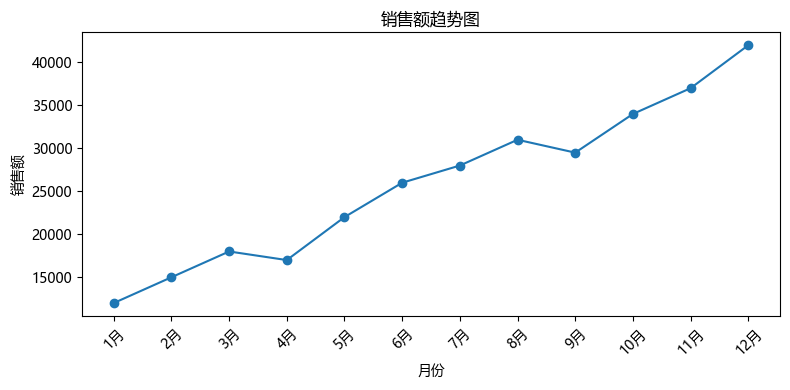


    ### 👀 消息预览

    下面这段内容将被发送到测试群：

    ---

    
        ### 🤖 AI 数据分析结果

        **📊 核心发现**
1. **全年业务呈强劲增长**：销售额从1月的1.2万增至12月的4.2万（+250%），订单量与客户数同步翻倍以上，整体扩张态势明确。
2. **增长靠规模驱动，客单价稳定**：经测算，全年单笔订单金额稳定在100~117元之间，单客月均下单频次维持在1.45~1.52次。说明业绩提升主要源于客户基数扩大，而非单次消费额拉升。
3. **下半年进入加速期**：7月起环比增幅明显扩大，10~12月各项指标持续冲高，年底呈现明显的冲刺特征。

**⚠️ 异常提示**
**4月与9月存在小幅回落**。这两个月的销售额、订单数与客户数均环比微降（如4月销售额较3月下降约5.6%），打破了逐月上涨的节奏。虽跌幅有限，但属于数据断点。

**💡 业务建议**
建议专项复盘4月、9月下滑的具体原因（如营销空窗、行业淡季等），并将10~12月验证有效的促单策略前置至年中应用，以平滑季度波动，实现全年业绩更均衡的增长。

        ---

        ### 📈 AI 推荐图表

        - 图表类型：line
        - 横轴：月份
        - 纵轴：销售额
        - 推荐原因：数据包含明确的时间序列（月份）与数值指标，折线图最适合直观展示销售额等关键指标随时间变化的趋势。

        图表已生成。
        

    ---
    

'消息已预览。请确认后再发送。'

In [46]:
analyze_and_send("data/sales_data.csv", confirm=False)